## SQL Database Connect

In [69]:
import pandas as pd
import pymysql
import matplotlib.pyplot as plt

# Connect once at the start
conn = pymysql.connect(
    host="localhost",
    user="root",
    password="***",
    database="ipl_db"
)
print("Database connected successfully!")

Database connected successfully!


In [71]:
import pandas as pd
import pymysql
import matplotlib.pyplot as plt
import seaborn as sns

# visual style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# Connect to MySQL
conn = pymysql.connect(
    host="localhost",
    user="root",
    password="***",
    database="ipl_db"
)

print("Connected to IPL MySQL Database!")

Connected to IPL MySQL Database!


In [73]:
import matplotlib.pyplot as plt
import pandas as pd
import pymysql
import seaborn as sns

# Professional visualization style
sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "sans-serif"

## Batting Performance Across Match Phases

C:\Users\ritik\AppData\Local\Temp\ipykernel_6884\3793899335.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_phase = pd.read_sql_query(query_phase, conn)


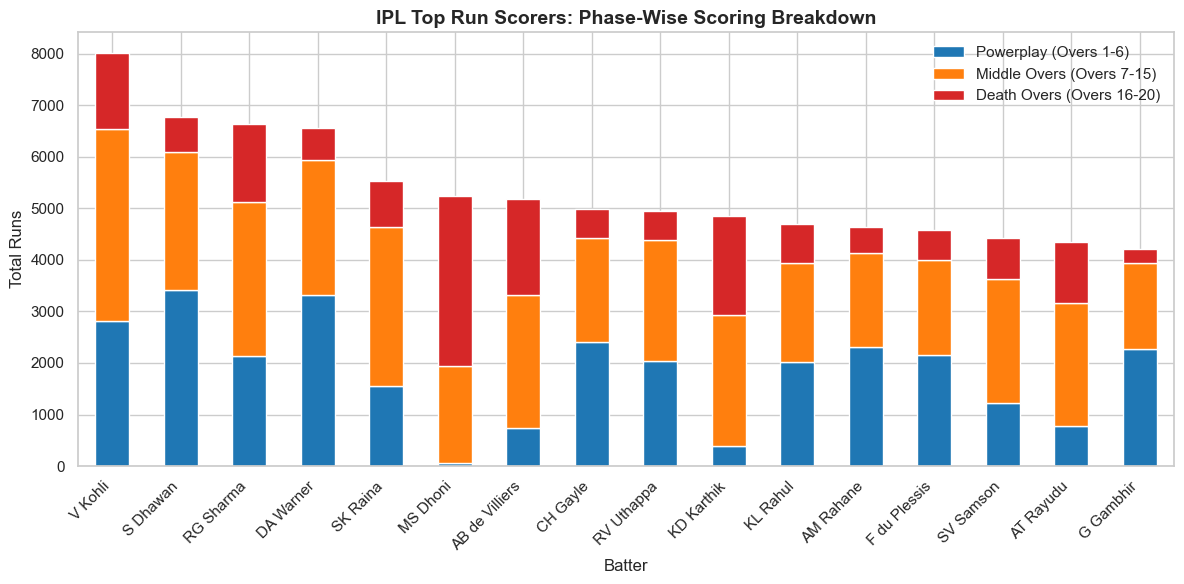

In [76]:
query_phase = """
    SELECT 
        batter,
        SUM(CASE WHEN `over` <= 5 THEN batsman_runs ELSE 0 END) AS powerplay_runs,
        SUM(CASE WHEN `over` BETWEEN 6 AND 14 THEN batsman_runs ELSE 0 END) AS middle_runs,
        SUM(CASE WHEN `over` >= 15 THEN batsman_runs ELSE 0 END) AS death_runs,
        SUM(batsman_runs) AS total_runs
    FROM deliveries
    GROUP BY batter
    HAVING total_runs >= 4000
    ORDER BY total_runs DESC;
"""

df_phase = pd.read_sql_query(query_phase, conn)

# Visualization: Stacked Bar Chart
df_phase.set_index('batter')[['powerplay_runs', 'middle_runs', 'death_runs']].plot(
    kind='bar', 
    stacked=True, 
    figsize=(12, 6),
    color=['#1f77b4', '#ff7f0e', '#d62728']
)

plt.title('IPL Top Run Scorers: Phase-Wise Scoring Breakdown', fontsize=14, fontweight='bold')
plt.xlabel('Batter', fontsize=12)
plt.ylabel('Total Runs', fontsize=12)
plt.legend(['Powerplay (Overs 1-6)', 'Middle Overs (Overs 7-15)', 'Death Overs (Overs 16-20)'])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("Batting Performance Across Match Phases.png", dpi=300)   # Save image 
plt.show()

## Identifying the Ultimate Death-Overs Finishers

C:\Users\ritik\AppData\Local\Temp\ipykernel_6884\3465538066.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_finishers = pd.read_sql_query(query_finishers, conn)


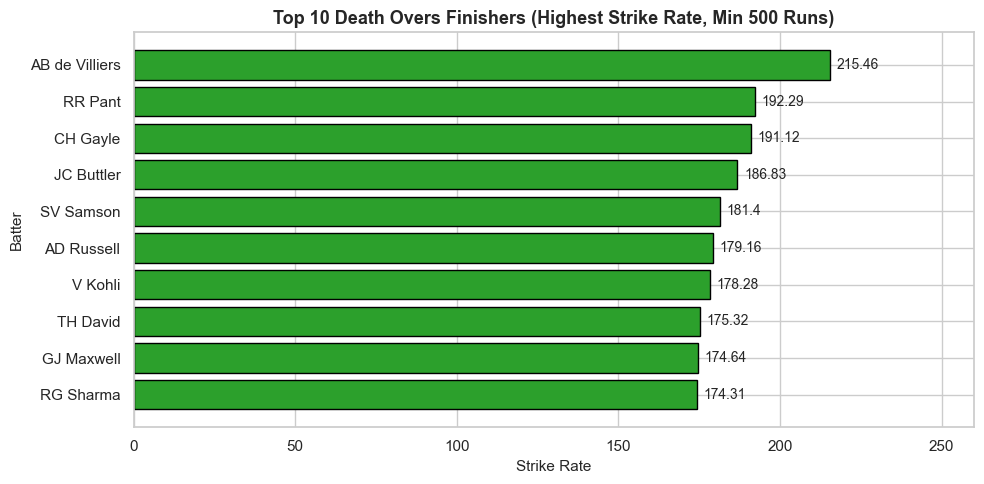

In [79]:
query_finishers = """
    SELECT 
        batter, 
        SUM(batsman_runs) AS death_runs,
        COUNT(ball) AS balls_faced,
        ROUND((SUM(batsman_runs) * 100.0) / COUNT(ball), 2) AS strike_rate
    FROM deliveries
    WHERE `over` >= 15
    GROUP BY batter
    HAVING death_runs >= 500
    ORDER BY strike_rate DESC
    LIMIT 10;
"""

df_finishers = pd.read_sql_query(query_finishers, conn)

# Horizontal Bar Chart
plt.figure(figsize=(10, 5))
bars = plt.barh(df_finishers['batter'], df_finishers['strike_rate'], color='#2ca02c', edgecolor='black')

plt.title('Top 10 Death Overs Finishers (Highest Strike Rate, Min 500 Runs)', fontsize=13, fontweight='bold')
plt.xlabel('Strike Rate', fontsize=11)
plt.ylabel('Batter', fontsize=11)
plt.gca().invert_yaxis()

# Add values next to the bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + 2, bar.get_y() + bar.get_height()/2, f'{width}', va='center', fontsize=10)

plt.xlim(0, 260)
plt.tight_layout()
plt.savefig("Death-Overs Finishers.png", dpi=300)
plt.show()

## Death Overs Bowlers with Best Economy Rates

C:\Users\ritik\AppData\Local\Temp\ipykernel_6884\2959778887.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_death_bowlers = pd.read_sql_query(query_death_bowlers, conn)


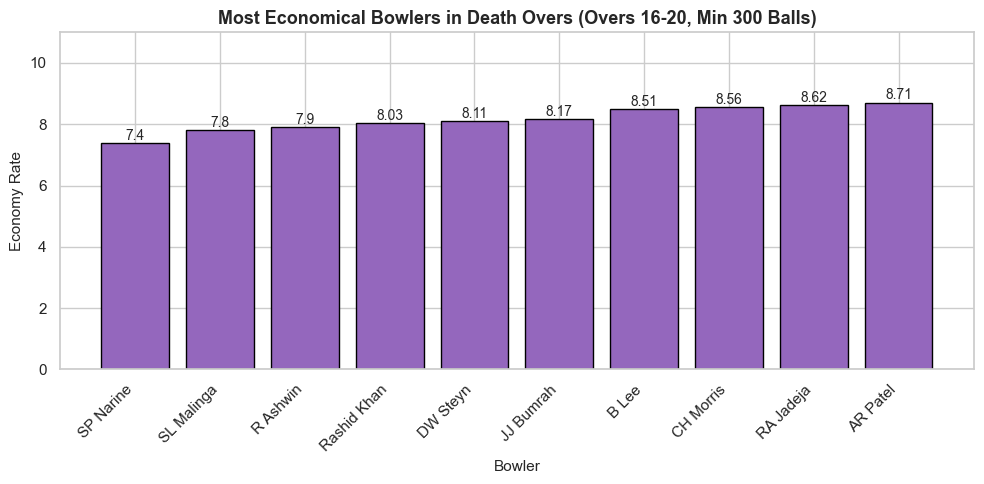

In [82]:
query_death_bowlers = """
    SELECT 
        bowler,
        COUNT(ball) AS death_balls,
        SUM(total_runs) AS runs_given,
        ROUND((SUM(total_runs) * 6.0) / COUNT(ball), 2) AS economy_rate
    FROM deliveries
    WHERE `over` >= 15
    GROUP BY bowler
    HAVING death_balls >= 300
    ORDER BY economy_rate ASC
    LIMIT 10;
"""

df_death_bowlers = pd.read_sql_query(query_death_bowlers, conn)

# 2. Visual Plot
plt.figure(figsize=(10, 5))
bars = plt.bar(df_death_bowlers['bowler'], df_death_bowlers['economy_rate'], color='#9467bd', edgecolor='black')

plt.title('Most Economical Bowlers in Death Overs (Overs 16-20, Min 300 Balls)', fontsize=13, fontweight='bold')
plt.xlabel('Bowler', fontsize=11)
plt.ylabel('Economy Rate', fontsize=11)
plt.xticks(rotation=45, ha='right')

# Add economy values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.1, f'{height}', ha='center', fontsize=10)

plt.ylim(0, 11)
plt.tight_layout()
plt.savefig("Death Overs Bowlers with Best Economy Rates.png", dpi=300)
plt.show()

## Match Winning Impact (Most Player of the Match Awards)

In [85]:
query_mom = """
    SELECT 
        player_of_match, 
        COUNT(*) AS total_awards
    FROM matches
    WHERE player_of_match IS NOT NULL
    GROUP BY player_of_match
    ORDER BY total_awards DESC
    LIMIT 10;
"""

df_mom = pd.read_sql_query(query_mom, conn)

print("--- TOP 10 MATCH WINNERS (MAN OF THE MATCH) ---")
print(df_mom.to_string(index=False))

--- TOP 10 MATCH WINNERS (MAN OF THE MATCH) ---
player_of_match  total_awards
 AB de Villiers            25
       CH Gayle            22
      RG Sharma            19
      DA Warner            18
        V Kohli            18
       MS Dhoni            17
      RA Jadeja            16
      SR Watson            16
      YK Pathan            16
      SP Narine            15


C:\Users\ritik\AppData\Local\Temp\ipykernel_6884\337441310.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_mom = pd.read_sql_query(query_mom, conn)


## Boundary Reliance Index (Power Hitters)

C:\Users\ritik\AppData\Local\Temp\ipykernel_6884\3304235318.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_boundary = pd.read_sql_query(query_boundary, conn)


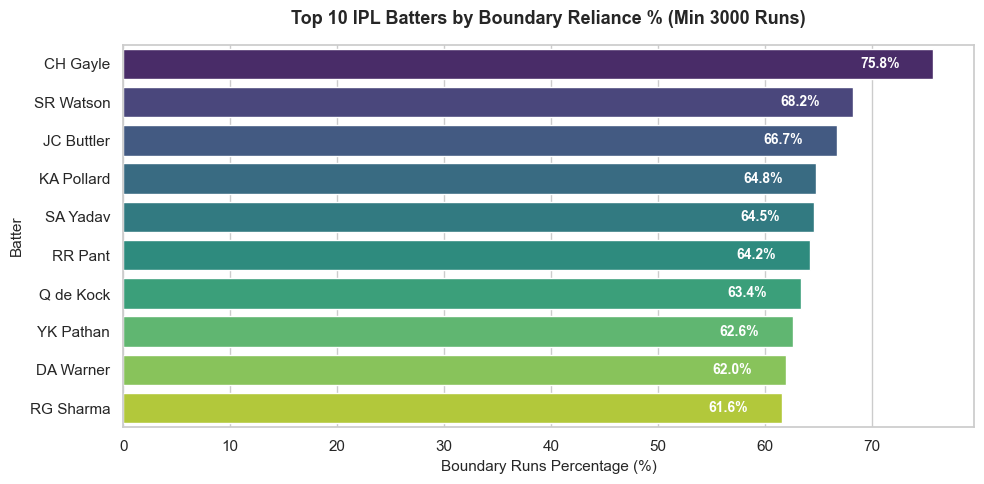

In [88]:
query_boundary = """
    SELECT 
        batter,
        SUM(batsman_runs) AS total_runs,
        SUM(CASE WHEN batsman_runs IN (4, 6) THEN batsman_runs ELSE 0 END) AS boundary_runs,
        ROUND((SUM(CASE WHEN batsman_runs IN (4, 6) THEN batsman_runs ELSE 0 END) * 100.0) / SUM(batsman_runs), 2) AS boundary_runs_pct
    FROM deliveries
    GROUP BY batter
    HAVING SUM(batsman_runs) >= 3000
    ORDER BY boundary_runs_pct DESC
    LIMIT 10;
"""

df_boundary = pd.read_sql_query(query_boundary, conn)

# Seaborn Horizontal Bar Plot
plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=df_boundary,
    x="boundary_runs_pct",
    y="batter",
    palette="viridis",
    hue="batter",
)

plt.title(
    "Top 10 IPL Batters by Boundary Reliance % (Min 3000 Runs)",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Boundary Runs Percentage (%)", fontsize=11)
plt.ylabel("Batter", fontsize=11)

# Add data labels inside bars
for p in ax.patches:
    width = p.get_width()
    ax.annotate(
        f"{width:.1f}%",
        (width - 5, p.get_y() + p.get_height() / 2.0),
        ha="center",
        va="center",
        color="white",
        fontweight="bold",
        fontsize=10,
    )

plt.tight_layout()
plt.savefig("boundary_reliance.png", dpi=300)  # image save
plt.show()

## Miserly Bowlers (Highest Dot Ball %)

C:\Users\ritik\AppData\Local\Temp\ipykernel_6884\3997280060.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_dots = pd.read_sql_query(query_dots, conn)


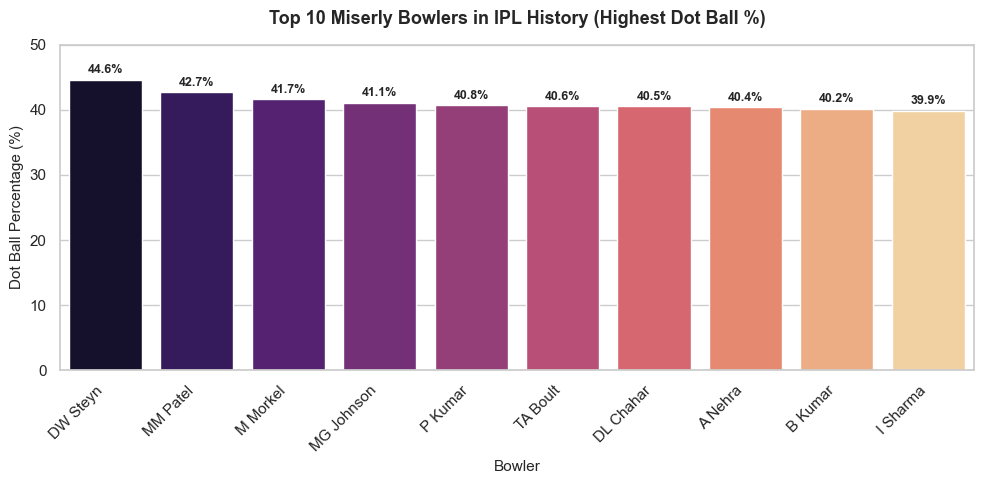

In [91]:
query_dots = """
    SELECT 
        bowler,
        COUNT(ball) AS total_balls,
        SUM(CASE WHEN total_runs = 0 THEN 1 ELSE 0 END) AS dot_balls,
        ROUND((SUM(CASE WHEN total_runs = 0 THEN 1 ELSE 0 END) * 100.0) / COUNT(ball), 2) AS dot_ball_pct
    FROM deliveries
    GROUP BY bowler
    HAVING total_balls >= 1000
    ORDER BY dot_ball_pct DESC
    LIMIT 10;
"""

df_dots = pd.read_sql_query(query_dots, conn)

# Seaborn Bar Plot
plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=df_dots, x="bowler", y="dot_ball_pct", palette="magma", hue="bowler"
)

plt.title(
    "Top 10 Miserly Bowlers in IPL History (Highest Dot Ball %)",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Bowler", fontsize=11)
plt.ylabel("Dot Ball Percentage (%)", fontsize=11)
plt.xticks(rotation=45, ha="right")

# Add values above bars
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1f}%",
        (p.get_x() + p.get_width() / 2.0, p.get_height() + 0.5),
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
    )

plt.ylim(0, 50)
plt.tight_layout()
plt.savefig("dot_ball_percentage.png", dpi=300)
plt.show()

## Toss Impact Across Major IPL Venues

C:\Users\ritik\AppData\Local\Temp\ipykernel_6884\4112907848.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_toss = pd.read_sql_query(query_toss, conn)


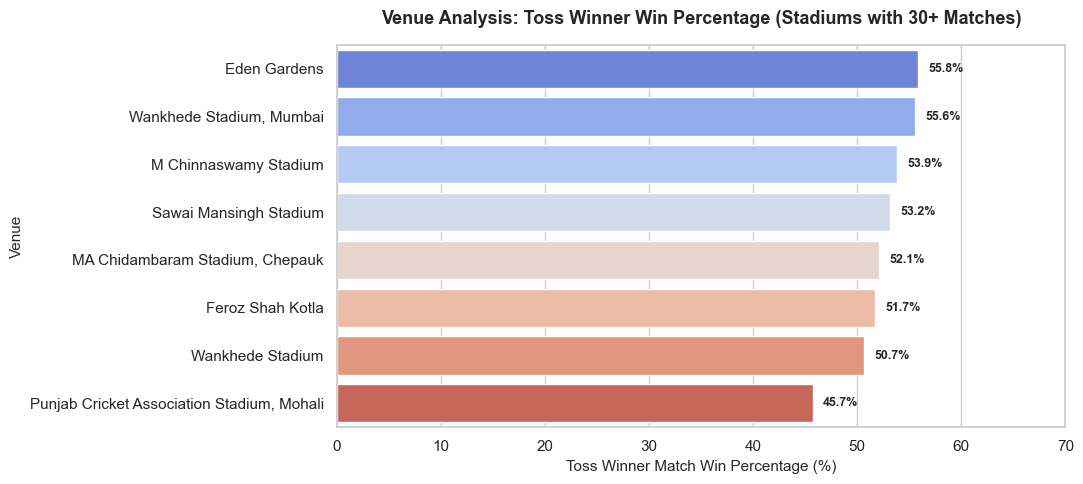

In [94]:
query_toss = """
    SELECT 
        venue,
        COUNT(*) AS total_matches,
        SUM(CASE WHEN toss_winner = winner THEN 1 ELSE 0 END) AS toss_win_and_match_win,
        ROUND((SUM(CASE WHEN toss_winner = winner THEN 1 ELSE 0 END) * 100.0) / COUNT(*), 2) AS toss_win_match_win_pct
    FROM matches
    GROUP BY venue
    HAVING total_matches >= 30
    ORDER BY toss_win_match_win_pct DESC
    LIMIT 8;
"""

df_toss = pd.read_sql_query(query_toss, conn)

# Horizontal Bar Chart
plt.figure(figsize=(11, 5))
ax = sns.barplot(
    data=df_toss,
    x="toss_win_match_win_pct",
    y="venue",
    palette="coolwarm",
    hue="venue",
)

plt.title(
    "Venue Analysis: Toss Winner Win Percentage (Stadiums with 30+ Matches)",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Toss Winner Match Win Percentage (%)", fontsize=11)
plt.ylabel("Venue", fontsize=11)

# Add annotations
for p in ax.patches:
    width = p.get_width()
    ax.annotate(
        f"{width:.1f}%",
        (width + 1, p.get_y() + p.get_height() / 2.0),
        ha="left",
        va="center",
        fontsize=9,
        fontweight="bold",
    )

plt.xlim(0, 70)
plt.tight_layout()
plt.savefig("toss_impact_venues.png", dpi=300)
plt.show()

## High-Pressure Clutch Chasers (Chasing Target >= 200)

C:\Users\ritik\AppData\Local\Temp\ipykernel_6884\82259787.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_chase = pd.read_sql_query(query_chase, conn)


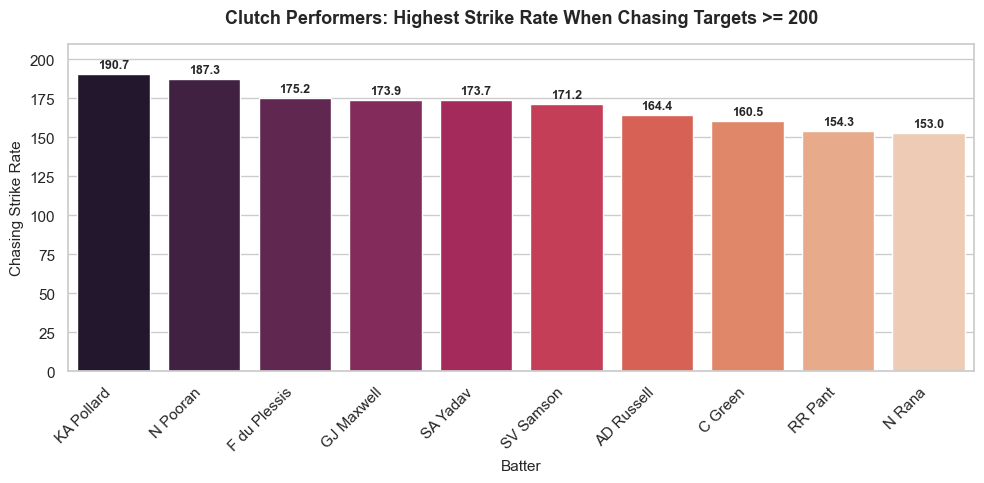

In [97]:
query_chase = """
    SELECT 
        d.batter,
        SUM(d.batsman_runs) AS chasing_runs,
        COUNT(DISTINCT d.match_id) AS innings_played,
        ROUND((SUM(d.batsman_runs) * 100.0) / COUNT(d.ball), 2) AS chasing_strike_rate
    FROM deliveries d
    JOIN matches m ON d.match_id = m.match_id
    WHERE d.inning = 2 AND CAST(m.target_runs AS UNSIGNED) >= 200
    GROUP BY d.batter
    HAVING chasing_runs >= 300
    ORDER BY chasing_strike_rate DESC
    LIMIT 10;
"""

df_chase = pd.read_sql_query(query_chase, conn)

# Visualizing with Seaborn
plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=df_chase,
    x="batter",
    y="chasing_strike_rate",
    palette="rocket",
    hue="batter",
)

plt.title(
    "Clutch Performers: Highest Strike Rate When Chasing Targets >= 200",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Batter", fontsize=11)
plt.ylabel("Chasing Strike Rate", fontsize=11)
plt.xticks(rotation=45, ha="right")

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1f}",
        (p.get_x() + p.get_width() / 2.0, p.get_height() + 2),
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
    )

plt.ylim(0, 210)
plt.tight_layout()
plt.savefig("high_pressure_chasers.png", dpi=300)
plt.show()